In [2]:
#imports are implemented here
import os
import pandas as pd
import numpy as np


DATA PREPERATION by reading data from Stock files
1. Sort by Date 
2. Data Type and Format Validation
3.  Missing or Null Values 
4. Validate Price Relationships 
5. Handling duplicate data 
6. Remove Non-Trading Days if present 
7. Outlier Detection and Treatment 


In [3]:
# Read from Data set path
from pathlib import Path
base_dir = Path.cwd()
dataset_csv   =  pd.read_csv(base_dir / "DATA" / "Stock_File_1.csv")
dataset_txt    =  pd.read_csv(base_dir / "DATA" / "Stock_File_2.txt")
print(dataset_csv)
print(dataset_txt)
print("CSV Date Type:", dataset_csv['Date'].dtype)
print("TXT Date Type:", dataset_txt['Date'].dtype)
# Merging both datasets
ds = pd.concat([dataset_csv, dataset_txt], ignore_index=True)
print(ds)



          Date    Open    High    Low   Close Volume
0     1-Jun-06  471.60  474.00  442.0  444.42  21900
1    12-Jun-06  454.00  464.00  440.0  446.17   8400
2    22-Jun-06  451.16  464.20  447.6  460.26  19400
3     3-Jul-06  495.10  509.68  493.0  498.97   9100
4    13-Jul-06  518.00  526.40  517.0  521.66   6800
..         ...     ...     ...    ...     ...    ...
160  11-Nov-10     NaN  898.00  855.0  857.95  27300
161  22-Nov-10  840.00  859.95  824.6  850.40  10200
162   1-Dec-10  769.00  814.00  765.2  794.05  20600
163  10-Dec-10  762.00  774.00  751.0  759.70  17400
164  21-Dec-10  770.00  775.00  752.2  760.70  24500

[165 rows x 6 columns]
          Date     Open     High      Low    Close Volume
0     3-Jan-11   798.00   824.95   796.00   810.55  17600
1    13-Jan-11   748.10   768.00      NaN   752.85  13000
2    24-Jan-11   741.00   626.01   732.55      NaN   8700
3     1-Feb-11   753.00   753.00   712.10   717.25  23700
4    11-Feb-11   647.90   654.55   626.35   642.40

• Ensure the final dataset (after merging) is sorted chronologically by Date.
• Date: Convert to datetime format (YYYY-MM-DD). Ensure no null or 
malformed dates.  

In [4]:
#Date Format Validation 
# converting 'Date' column to datetime format YYYY-MM-DD
ds['Date'] = pd.to_datetime(ds['Date'], format='%d-%b-%y').dt.strftime('%Y-%m-%d')

# Sorting dataset by Date column
ds.sort_values(by=['Date'], inplace=True)
print(ds['Date'])

0      2006-06-01
1      2006-06-12
2      2006-06-22
3      2006-07-03
4      2006-07-13
          ...    
364    2016-07-11
365    2016-07-21
366    2016-08-01
367    2016-08-11
368    2016-08-22
Name: Date, Length: 369, dtype: object



Data Type and Format Validation  

• If any numerical variable value is recorded in the file as a string type instead of 
numerical data type, convert it to numerical data type (int or float). 
• Price Variables (Open, High, Low, Close): Convert to float. Remove any 
currency symbols or strings if present. 
• Volume: Convert to int or float (as needed). Ensure it is non-negative. 

In [5]:
#DataType Validation 
ds.info()
ds['Volume'].describe()
non_numeric_values = ds[pd.to_numeric(ds['Volume'], errors='coerce').isna()]['Volume'].unique()
print("Non-numeric values in 'Volume' column:", non_numeric_values)
print(ds[ds['Volume'] == 'zero'])

ds['Volume'] = ds['Volume'].replace("zero", 0)

ds['Volume'] = ds['Volume'].astype(int)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    369 non-null    object 
 1   Open    362 non-null    float64
 2   High    353 non-null    float64
 3   Low     356 non-null    float64
 4   Close   355 non-null    float64
 5   Volume  369 non-null    object 
dtypes: float64(4), object(2)
memory usage: 17.4+ KB
Non-numeric values in 'Volume' column: ['zero']
           Date     Open     High      Low    Close Volume
103  2009-04-10   458.75   458.75   458.75   458.75   zero
105  2009-05-01  1447.35   487.35   487.35   487.35   zero
119  2009-09-21  1755.80   795.80   795.80   795.80   zero
123  2009-11-02  1727.85   767.85   767.85   767.85   zero
129  2010-01-01   767.25   767.25   767.25   767.25   zero
213  2012-05-01  1778.00   818.00   818.00   818.00   zero
249  2013-05-01   519.55   519.55   519.55   519.55   zero
285  2014-05-01  1800.45   

 Missing or Null Values 
• Drop rows with nulls in any of these columns: Date, Open, High, Low, Close, 
Volume. 
• Alternatively (if essential), perform data imputation using appropriate strategy 
for each variable. Example: Impute “Volume” with rolling average or median 
over last 5 valid trading days 

In [6]:
#Missing or Null Values Handling
print(ds['Open'].isnull().sum())
print(ds['High'].isnull().sum())
print(ds['Close'].isnull().sum())
print(ds['Low'].isnull().sum()) 
print(ds['Volume'].isnull().sum())
ds.info()
# Create a list of the specific columns to check for nulls
columns_to_check = ['Open', 'Close', 'Low', 'High', 'Volume']

columns_to_fill_ffill = ['Open', 'High', 'Low', 'Close']

# Fill missing values with the last valid observation
ds[columns_to_fill_ffill] = ds[columns_to_fill_ffill].ffill()

# Drop rows that have any nulls in the specified columns
#ds = ds.dropna(subset=columns_to_check)
ds.shape
ds.info()


7
16
14
13
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    369 non-null    object 
 1   Open    362 non-null    float64
 2   High    353 non-null    float64
 3   Low     356 non-null    float64
 4   Close   355 non-null    float64
 5   Volume  369 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 17.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    369 non-null    object 
 1   Open    369 non-null    float64
 2   High    369 non-null    float64
 3   Low     369 non-null    float64
 4   Close   369 non-null    float64
 5   Volume  369 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 17.4+ KB


 Validate Price Relationships 
• Ensure logical integrity of price data. Example: Low ≤ Open ≤ High, Low ≤ 
Close ≤ High 
• Drop rows violating this unless explainable (e.g., erroneous recording) 

Validate Price Relationships 
• Ensure logical integrity of price data. Example: Low ≤ Open ≤ High, Low ≤ 
Close ≤ High 
• Drop rows violating this unless explainable (e.g., erroneous recording) 

In [9]:
#Validate Price Relationships Low ≤ Open ≤ High, Low ≤ Close ≤ High 
ds = ds[(ds['Low'] <= ds['Open']) & (ds['Open'] <= ds['High']) & (ds['Low'] <= ds['Close']) & (ds['Close'] <= ds['High'])]
ds.reset_index(drop=True, inplace=True)
print(ds)

           Date     Open     High     Low    Close  Volume
0    2006-06-01   471.60   474.00   442.0   444.42   21900
1    2006-06-12   454.00   464.00   440.0   446.17    8400
2    2006-06-22   451.16   464.20   447.6   460.26   19400
3    2006-07-03   495.10   509.68   493.0   498.97    9100
4    2006-07-13   518.00   526.40   517.0   521.66    6800
..          ...      ...      ...     ...      ...     ...
314  2016-07-01  1225.20  1240.00  1216.2  1223.85    7000
315  2016-07-11  1265.50  1287.00  1216.2  1276.40   11800
316  2016-07-21  1301.00  1322.10  1261.0  1270.55   36800
317  2016-08-01  1279.65  1322.10  1247.4  1250.65    4600
318  2016-08-22  1168.20  1168.20  1148.4  1155.55    2600

[319 rows x 6 columns]


In [ ]:
#handling duplicates
#show duplicate rows
duplicate_rows = ds[ds.duplicated()]
print("Duplicate rows:")
print(duplicate_rows)   
#remove duplicate rows is not needed as there  are no duplicates
#ds = ds.drop_duplicates()
#ds.reset_index(drop=True, inplace=True)

Duplicate rows:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume]
Index: []


Remove Non-Trading Days if present 
• Filter out rows where Open = High = Low = Close and Volume = 0 
• These are non-trading days and should not be used for modeling 

In [ ]:
# show out rows where open = high = low = close and volume = 0
nontrading_rows = ds[(ds['Open'] == ds['High']) & (ds['High'] == ds['Low']) & (ds['Low'] == ds['Close']) & (ds['Volume'] == 0)]
print("Non-trading rows where Open = High = Low = Close and Volume = 0:")
print(nontrading_rows)
# filter out rows where open = high = low = close and volume = 0
ds = ds[~((ds['Open'] == ds['High']) & (ds['High'] == ds['Low']) & (ds['Low'] == ds['Close']) & (ds['Volume'] == 0))]
ds.reset_index(drop=True, inplace=True)

Outlier rows where Open = High = Low = Close and Volume = 0:
           Date     Open     High      Low    Close  Volume
90   2009-04-10   458.75   458.75   458.75   458.75       0
109  2010-01-01   767.25   767.25   767.25   767.25       0
210  2013-05-01   519.55   519.55   519.55   519.55       0
290  2015-10-22  1237.75  1237.75  1237.75  1237.75       0
292  2015-11-12  1201.70  1201.70  1201.70  1201.70       0


Outlier Detection and Treatment 
• Identify extreme outliers in Price and Volume using appropriate method and verify 
once using visual inspection. 
• Investigate the outliers and take suitable actions. Example: Removal of outliers 
if it is due to data error 

Outliers detected:
           Date     Open     High      Low    Close  Volume
18   2006-12-11   767.00   789.00   740.00   758.22  130800
35   2007-07-02  1090.00  1148.00  1090.00  1114.75  412100
36   2007-07-12  1085.90  1124.90  1085.90  1114.75  110800
37   2007-07-23  1061.00  1147.40  1061.00  1136.10  121000
38   2007-08-01  1125.00  1125.00  1077.00  1081.55  152500
39   2007-08-10  1050.00  1103.00  1050.00  1086.20  219700
44   2007-10-22  1386.00  1435.00  1327.00  1376.55  165200
45   2007-11-01  1614.00  1650.00  1565.00  1590.75  203500
47   2007-12-24  1490.00  1500.00  1445.00  1456.05  108900
51   2008-02-01  1130.00  1176.00  1079.15  1132.70  133300
54   2008-03-03  1137.00  1137.00  1095.00  1109.65  230300
55   2008-03-13  1102.00  1128.00  1080.00  1103.30  138500
61   2008-05-22  1029.00  1030.90   996.50  1001.10  107800
62   2008-06-02  1040.00  1065.00  1015.05  1025.65  151200
66   2008-07-21   900.00   914.95   878.50   891.05  116800
67   2008-08-01   765

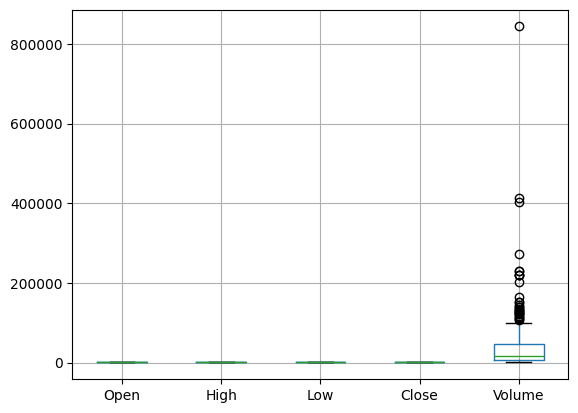

Data after removing outliers:
           Date     Open     High     Low    Close  Volume
0    2006-06-01   471.60   474.00   442.0   444.42   21900
1    2006-06-12   454.00   464.00   440.0   446.17    8400
2    2006-06-22   451.16   464.20   447.6   460.26   19400
3    2006-07-03   495.10   509.68   493.0   498.97    9100
4    2006-07-13   518.00   526.40   517.0   521.66    6800
..          ...      ...      ...     ...      ...     ...
279  2016-07-01  1225.20  1240.00  1216.2  1223.85    7000
280  2016-07-11  1265.50  1287.00  1216.2  1276.40   11800
281  2016-07-21  1301.00  1322.10  1261.0  1270.55   36800
282  2016-08-01  1279.65  1322.10  1247.4  1250.65    4600
283  2016-08-22  1168.20  1168.20  1148.4  1155.55    2600

[284 rows x 6 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    284 non-null    object 
 1   Open    284 non-nu

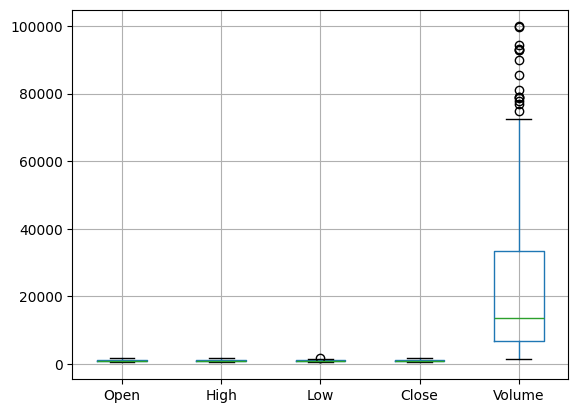

In [15]:
#Identify extreme outliers in Price and Volume using appropriate method and verify once using visual inspection. 
Q1 = ds[['Open', 'High', 'Low', 'Close', 'Volume']].quantile(0.25)
Q3 = ds[['Open', 'High', 'Low', 'Close', 'Volume']].quantile(0.75)
IQR = Q3 - Q1
outliers = ds[((ds[['Open', 'High', 'Low', 'Close', 'Volume']] < (Q1 - 1.5 * IQR)) | (ds[['Open', 'High', 'Low', 'Close', 'Volume']] > (Q3 + 1.5 * IQR))).any(axis=1)]
print("Outliers detected:")
print(outliers)
# box plot for visual inspection
import matplotlib.pyplot as plt 
ds[['Open', 'High', 'Low', 'Close', 'Volume']].boxplot()
plt.show()
#Removing outliers
ds = ds[~((ds[['Open', 'High', 'Low', 'Close', 'Volume']] < (Q1 - 1.5 * IQR)) | (ds[['Open', 'High', 'Low', 'Close', 'Volume']] > (Q3 + 1.5 * IQR))).any(axis=1)]
ds.reset_index(drop=True, inplace=True)
print("Data after removing outliers:")
print(ds)

#Final dataset info
ds.info()
#box plot after removing outliers
ds[['Open', 'High', 'Low', 'Close', 'Volume']].boxplot()
plt.show()  



